In [1]:
# ══════════════════════════════════════════════════════
# THE WEEK 1 CONNECTION MAP
# Understanding HOW concepts relate to each other
# ══════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════╗
║            WEEK 1 — HOW EVERYTHING CONNECTS             ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  PROBABILITY (Day 1)                                     ║
║  └── Bayes' Theorem                                      ║
║       ├── Prior × Likelihood = Posterior                 ║
║       ├── MLE (no prior) → minimise Cross-Entropy loss   ║
║       └── MAP (with prior) → adds Regularisation         ║
║            ├── Gaussian prior → L2 regularisation        ║
║            └── Laplace prior  → L1 regularisation        ║
║                                                          ║
║  BIAS-VARIANCE (Day 1)                                   ║
║  └── Controls model complexity decisions                 ║
║       ├── High bias  → simpler model, more regularisation║
║       └── High variance → more data, less regularisation ║
║                                                          ║
║  REGRESSION (Day 2)                                      ║
║  ├── Linear regression → MSE loss (Gaussian assumption)  ║
║  ├── Logistic regression → Cross-entropy loss (MLE)      ║
║  └── Both use Gradient Descent at scale                  ║
║                                                          ║
║  TREES (Day 3)                                           ║
║  ├── Decision Tree → splits on Information Gain          ║
║  ├── Random Forest → Bagging + feature subsampling       ║
║  │    └── Reduces VARIANCE (parallel, independent)       ║
║  └── Gradient Boosting → sequential residual fitting     ║
║       └── Reduces BIAS + VARIANCE (but can overfit)      ║
║                                                          ║
║  SVM (Day 4)                                             ║
║  ├── Linear → maximum margin hyperplane                  ║
║  └── Kernel → implicit high-dimensional mapping          ║
║       └── C controls bias-variance (like regularisation) ║
║                                                          ║
║  UNSUPERVISED (Day 4)                                    ║
║  ├── K-Means → E-M algorithm, spherical clusters         ║
║  ├── DBSCAN  → density-based, arbitrary shapes           ║
║  └── PCA     → variance-maximising projection            ║
║       └── Eigenvectors of covariance matrix              ║
║                                                          ║
║  EVALUATION (Day 5)                                      ║
║  ├── All metrics come from confusion matrix              ║
║  ├── CV → honest, leak-free performance estimate         ║
║  └── Pipeline → guarantees no leakage automatically      ║
║                                                          ║
║  PROJECT (Day 6)                                         ║
║  └── All of the above applied end-to-end                 ║
║       ├── EDA (stats) → Feature engineering              ║
║       ├── Modelling (Days 2-3) → Pipeline (Day 5)        ║
║       └── SHAP (Bayes/probability) → Business value      ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")

print(" THE KEY THREAD RUNNING THROUGH EVERYTHING:")
print()
print("Probability theory → Loss functions → Optimisation → Models")
print()
print("Every ML algorithm is answering the same question:")
print("'What are the most probable parameters given this data?'")
print("(That IS maximum likelihood estimation.)")
print()
print("Regularisation is just adding a prior to that question.")
print("Cross-validation is just asking it honestly.")
print("SHAP is just explaining the answer fairly.")
print()
print("Everything connects. Nothing is arbitrary.")


╔══════════════════════════════════════════════════════════╗
║            WEEK 1 — HOW EVERYTHING CONNECTS             ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  PROBABILITY (Day 1)                                     ║
║  └── Bayes' Theorem                                      ║
║       ├── Prior × Likelihood = Posterior                 ║
║       ├── MLE (no prior) → minimise Cross-Entropy loss   ║
║       └── MAP (with prior) → adds Regularisation         ║
║            ├── Gaussian prior → L2 regularisation        ║
║            └── Laplace prior  → L1 regularisation        ║
║                                                          ║
║  BIAS-VARIANCE (Day 1)                                   ║
║  └── Controls model complexity decisions                 ║
║       ├── High bias  → simpler model, more regularisation║
║       └── High variance → more data, less regularisation ║
║                       

MLE vs MAP — THE CORE DIFFERENCE

QUESTION: You flip a coin 5 times. Get 5 heads.
What's the probability of heads?

MLE answer: 1.0
(MLE says: 100% heads. Only trusts the data.)
(With only 5 flips this is clearly wrong!)

MAP answer: 0.86
(MAP says: ~57% heads. Prior pulls it toward fair coin.)

KEY INSIGHT:
As n → large, MAP → MLE (data overwhelms the prior)
As n → small, MAP → prior (prior dominates when data is scarce)

REGULARISATION CONNECTION:
MAP with Gaussian prior = L2 regularisation (Ridge)
MAP with Laplace prior  = L1 regularisation (Lasso)
The 'prior' is the regularisation. They are the same thing.


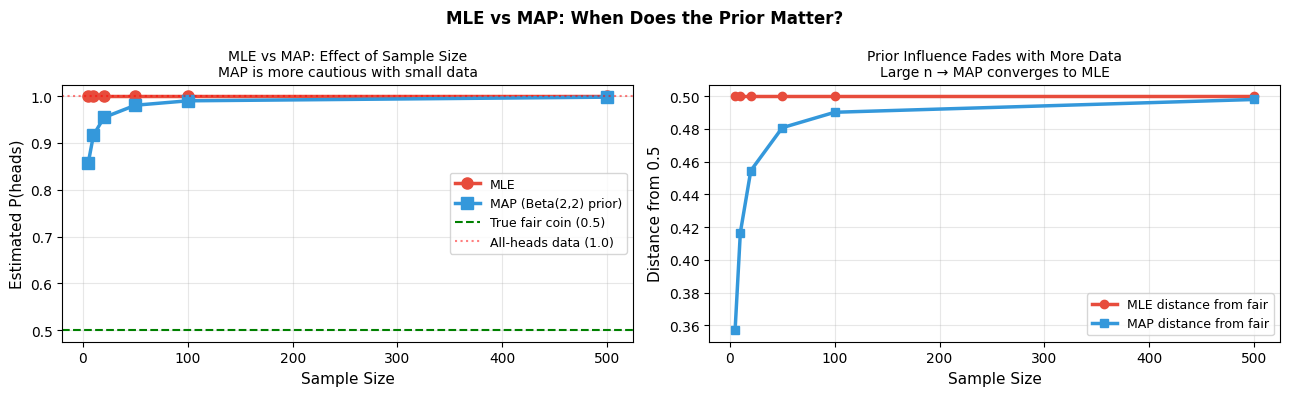

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

print("MLE vs MAP — THE CORE DIFFERENCE")
print("=" * 50)
print()
print("QUESTION: You flip a coin 5 times. Get 5 heads.")
print("What's the probability of heads?")
print()

# MLE answer: just maximise the data likelihood
# P(5 heads | p) = p^5 → maximised at p=1.0
mle_estimate = 1.0
print(f"MLE answer: {mle_estimate:.1f}")
print("(MLE says: 100% heads. Only trusts the data.)")
print("(With only 5 flips this is clearly wrong!)")
print()

# MAP answer: use a prior belief (coin is probably fair)
# Prior: Beta(2,2) — slight belief toward fairness
# Posterior mode for Beta-Binomial:
# MAP = (heads + alpha - 1) / (n + alpha + beta - 2)
alpha, beta_param = 2, 2  # prior: slight fairness belief
heads, n = 5, 5
map_estimate = (heads + alpha - 1) / (n + alpha + beta_param - 2)
print(f"MAP answer: {map_estimate:.2f}")
print("(MAP says: ~57% heads. Prior pulls it toward fair coin.)")
print()
print("KEY INSIGHT:")
print("As n → large, MAP → MLE (data overwhelms the prior)")
print("As n → small, MAP → prior (prior dominates when data is scarce)")
print()
print("REGULARISATION CONNECTION:")
print("MAP with Gaussian prior = L2 regularisation (Ridge)")
print("MAP with Laplace prior  = L1 regularisation (Lasso)")
print("The 'prior' is the regularisation. They are the same thing.")

# Visualise how MAP shifts toward prior with small data
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sample_sizes = [5, 10, 20, 50, 100, 500]
mle_ests = []
map_ests = []

for n_size in sample_sizes:
    # Simulate: 100% heads rate (worst case)
    h = n_size  # all heads
    mle_ests.append(h / n_size)
    map_ests.append((h + alpha - 1) /
                    (n_size + alpha + beta_param - 2))

axes[0].plot(sample_sizes, mle_ests, 'o-',
             color='#E74C3C', linewidth=2.5,
             markersize=8, label='MLE')
axes[0].plot(sample_sizes, map_ests, 's-',
             color='#3498DB', linewidth=2.5,
             markersize=8, label='MAP (Beta(2,2) prior)')
axes[0].axhline(0.5, color='green', linestyle='--',
                linewidth=1.5, label='True fair coin (0.5)')
axes[0].axhline(1.0, color='red', linestyle=':',
                alpha=0.5, label='All-heads data (1.0)')
axes[0].set_xlabel("Sample Size", fontsize=11)
axes[0].set_ylabel("Estimated P(heads)", fontsize=11)
axes[0].set_title("MLE vs MAP: Effect of Sample Size\n"
                   "MAP is more cautious with small data",
                   fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Show prior influence fading
map_pull = [abs(m - 0.5) for m in map_ests]
mle_pull = [abs(m - 0.5) for m in mle_ests]

axes[1].plot(sample_sizes, mle_pull, 'o-',
             color='#E74C3C', linewidth=2.5,
             label='MLE distance from fair')
axes[1].plot(sample_sizes, map_pull, 's-',
             color='#3498DB', linewidth=2.5,
             label='MAP distance from fair')
axes[1].set_xlabel("Sample Size", fontsize=11)
axes[1].set_ylabel("Distance from 0.5", fontsize=11)
axes[1].set_title("Prior Influence Fades with More Data\n"
                   "Large n → MAP converges to MLE",
                   fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle("MLE vs MAP: When Does the Prior Matter?",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

THE KERNEL TRICK — Simplest Possible Explanation

PROBLEM: Two classes arranged as inner/outer rings.
No straight line can separate them in 2D.

TRICK: Add a third dimension: z = x² + y²
       (distance from origin)

Now the inner ring (small x²+y²) and outer ring
(large x²+y²) ARE separable by a flat plane!

The kernel K(a,b) = (a·b)² computes the dot product
in this higher-dimensional space WITHOUT ever going there.
That's the trick: compute similarity in high-D cheaply.


/tmp/ipykernel_158/182850857.py:88: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_158/182850857.py:88: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


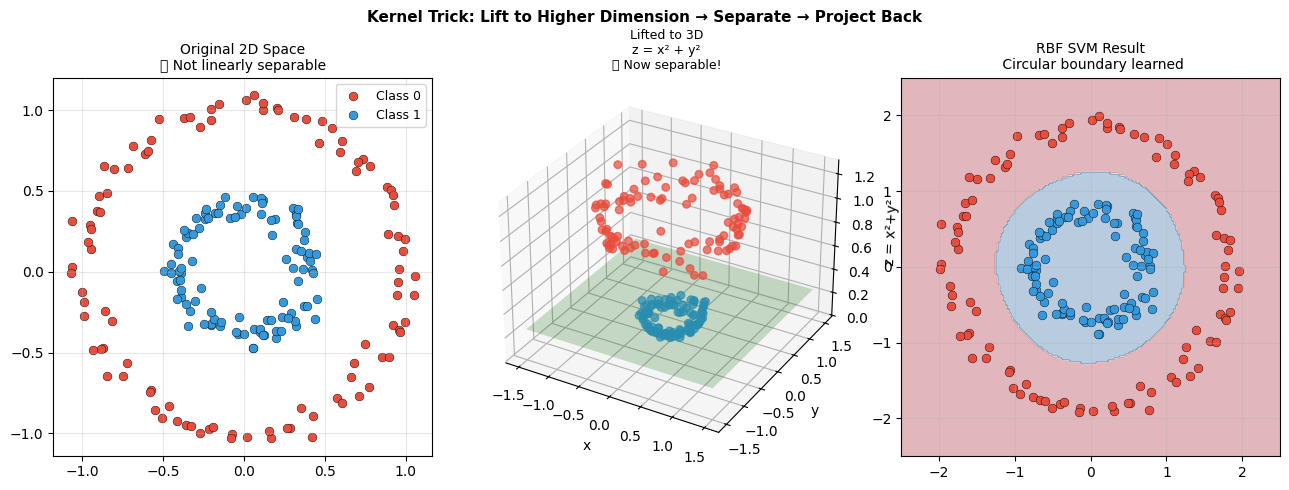

In [3]:
# The simplest possible kernel trick demonstration
print("THE KERNEL TRICK — Simplest Possible Explanation")
print("=" * 52)
print()
print("PROBLEM: Two classes arranged as inner/outer rings.")
print("No straight line can separate them in 2D.")
print()
print("TRICK: Add a third dimension: z = x² + y²")
print("       (distance from origin)")
print()
print("Now the inner ring (small x²+y²) and outer ring")
print("(large x²+y²) ARE separable by a flat plane!")
print()
print("The kernel K(a,b) = (a·b)² computes the dot product")
print("in this higher-dimensional space WITHOUT ever going there.")
print("That's the trick: compute similarity in high-D cheaply.")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

X_c, y_c = make_circles(n_samples=200, noise=0.05,
                          factor=0.4, random_state=42)

fig = plt.figure(figsize=(13, 5))

# 2D: not separable
ax1 = fig.add_subplot(131)
ax1.scatter(X_c[y_c==0,0], X_c[y_c==0,1],
            c='#E74C3C', s=40, edgecolors='k',
            linewidth=0.3, label='Class 0')
ax1.scatter(X_c[y_c==1,0], X_c[y_c==1,1],
            c='#3498DB', s=40, edgecolors='k',
            linewidth=0.3, label='Class 1')
ax1.set_title("Original 2D Space\n❌ Not linearly separable",
               fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.set_aspect('equal')

# 3D: separable after adding z = x² + y²
ax2 = fig.add_subplot(132, projection='3d')
z_coord = X_c[:,0]**2 + X_c[:,1]**2
ax2.scatter(X_c[y_c==0,0], X_c[y_c==0,1], z_coord[y_c==0],
            c='#E74C3C', s=30, alpha=0.7)
ax2.scatter(X_c[y_c==1,0], X_c[y_c==1,1], z_coord[y_c==1],
            c='#3498DB', s=30, alpha=0.7)

# Draw separating plane
xx_p = np.linspace(-1.5, 1.5, 15)
yy_p = np.linspace(-1.5, 1.5, 15)
XX_p, YY_p = np.meshgrid(xx_p, yy_p)
ZZ_p = np.full_like(XX_p, 0.25)
ax2.plot_surface(XX_p, YY_p, ZZ_p,
                  alpha=0.2, color='green')
ax2.set_title("Lifted to 3D\nz = x² + y²\n✅ Now separable!",
               fontsize=9)
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_zlabel('z = x²+y²')

# What RBF SVM sees
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

scaler_k = StandardScaler()
X_c_s = scaler_k.fit_transform(X_c)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma=1.0)
svm_rbf.fit(X_c_s, y_c)

ax3 = fig.add_subplot(133)
xx_b = np.linspace(-2.5, 2.5, 200)
yy_b = np.linspace(-2.5, 2.5, 200)
XX_b, YY_b = np.meshgrid(xx_b, yy_b)
Z_b = svm_rbf.predict(
    np.c_[XX_b.ravel(), YY_b.ravel()]).reshape(XX_b.shape)
ax3.contourf(XX_b, YY_b, Z_b, alpha=0.3, cmap='RdBu')
ax3.scatter(X_c_s[y_c==0,0], X_c_s[y_c==0,1],
            c='#E74C3C', s=40, edgecolors='k', linewidth=0.3)
ax3.scatter(X_c_s[y_c==1,0], X_c_s[y_c==1,1],
            c='#3498DB', s=40, edgecolors='k', linewidth=0.3)
ax3.set_title("RBF SVM Result\n Circular boundary learned",
               fontsize=10)
ax3.set_aspect('equal')
ax3.grid(alpha=0.3)

plt.suptitle("Kernel Trick: Lift to Higher Dimension → Separate → Project Back",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
print("SHAP VALUES — The Fairest Way to Explain a Prediction")
print("=" * 55)
print()
print("ANALOGY: A team of 3 players wins a prize of $100.")
print("How do you fairly split the prize?")
print()
print("Shapley (game theory, 1953): each player gets the")
print("AVERAGE marginal contribution they make across all")
print("possible team combinations they could be part of.")
print()
print("In ML: each feature gets the average contribution")
print("it makes to the prediction across all possible")
print("combinations of features.")
print()
print("RESULT: SHAP values always sum to:")
print("  prediction - average_prediction")
print()
print("Example:")
print("  Average model prediction:    0.25 (25% churn)")
print("  This customer's prediction:  0.72 (72% churn)")
print("  Sum of all SHAP values:      0.47")
print()
print("  contract_type=Month-to-month: +0.22  (pushes up)")
print("  tenure=2 months:              +0.15  (pushes up)")
print("  online_security=No:           +0.07  (pushes up)")
print("  total_charges (low):          +0.05  (pushes up)")
print("  tech_support=Yes:             -0.02  (pushes down)")
print("  ─────────────────────────────────────────────────")
print("  Sum:                          +0.47  ✅")
print()
print("This is why SHAP is the gold standard for explainability.")
print("It's mathematically grounded, not a heuristic.")

SHAP VALUES — The Fairest Way to Explain a Prediction

ANALOGY: A team of 3 players wins a prize of $100.
How do you fairly split the prize?

Shapley (game theory, 1953): each player gets the
AVERAGE marginal contribution they make across all
possible team combinations they could be part of.

In ML: each feature gets the average contribution
it makes to the prediction across all possible
combinations of features.

RESULT: SHAP values always sum to:
  prediction - average_prediction

Example:
  Average model prediction:    0.25 (25% churn)
  This customer's prediction:  0.72 (72% churn)
  Sum of all SHAP values:      0.47

  contract_type=Month-to-month: +0.22  (pushes up)
  tenure=2 months:              +0.15  (pushes up)
  online_security=No:           +0.07  (pushes up)
  total_charges (low):          +0.05  (pushes up)
  tech_support=Yes:             -0.02  (pushes down)
  ─────────────────────────────────────────────────
  Sum:                          +0.47  ✅

This is why SHAP is